In [3]:
import kagglehub # Download latest version
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
Path to dataset files: /kaggle/input/superstore-dataset-final


In [4]:
import pandas as pd

df = pd.read_csv('/kaggle/input/superstore-dataset-final/Sample - Superstore.csv', encoding='latin-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
import os
os.listdir('/kaggle/input/superstore-dataset-final')

['Sample - Superstore.csv']

In [7]:
# Shape — how many rows and columns
print("Shape:", df.shape)

# Column names and data types
print("\nData types:")
print(df.dtypes)

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

Shape: (9994, 21)

Data types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')
df['Year'] = df['Order Date'].dt.year
print(df['Order Date'].dtype)

datetime64[ns]


In [9]:
category = df.groupby('Category')[['Sales','Profit']].sum().round(2)
category['Profit Margin %'] = (category['Profit'] / category['Sales'] * 100).round(2)
category = category.sort_values('Sales', ascending=False)
print(category)

                     Sales     Profit  Profit Margin %
Category                                              
Technology       836154.03  145454.95            17.40
Furniture        741999.80   18451.27             2.49
Office Supplies  719047.03  122490.80            17.04


In [10]:
subcat = df.groupby('Sub-Category')[['Sales','Profit']].sum().round(2)
subcat['Profit Margin %'] = (subcat['Profit'] / subcat['Sales'] * 100).round(2)
subcat = subcat.sort_values('Profit', ascending=False)
print(subcat)

                  Sales    Profit  Profit Margin %
Sub-Category                                      
Copiers       149528.03  55617.82            37.20
Phones        330007.05  44515.73            13.49
Accessories   167380.32  41936.64            25.05
Paper          78479.21  34053.57            43.39
Binders       203412.73  30221.76            14.86
Chairs        328449.10  26590.17             8.10
Storage       223843.61  21278.83             9.51
Appliances    107532.16  18138.01            16.87
Furnishings    91705.16  13059.14            14.24
Envelopes      16476.40   6964.18            42.27
Art            27118.79   6527.79            24.07
Labels         12486.31   5546.25            44.42
Machines      189238.63   3384.76             1.79
Fasteners       3024.28    949.52            31.40
Supplies       46673.54  -1189.10            -2.55
Bookcases     114880.00  -3472.56            -3.02
Tables        206965.53 -17725.48            -8.56


In [11]:
loss = subcat[subcat['Profit'] < 0]
print(loss)

                  Sales    Profit  Profit Margin %
Sub-Category                                      
Supplies       46673.54  -1189.10            -2.55
Bookcases     114880.00  -3472.56            -3.02
Tables        206965.53 -17725.48            -8.56


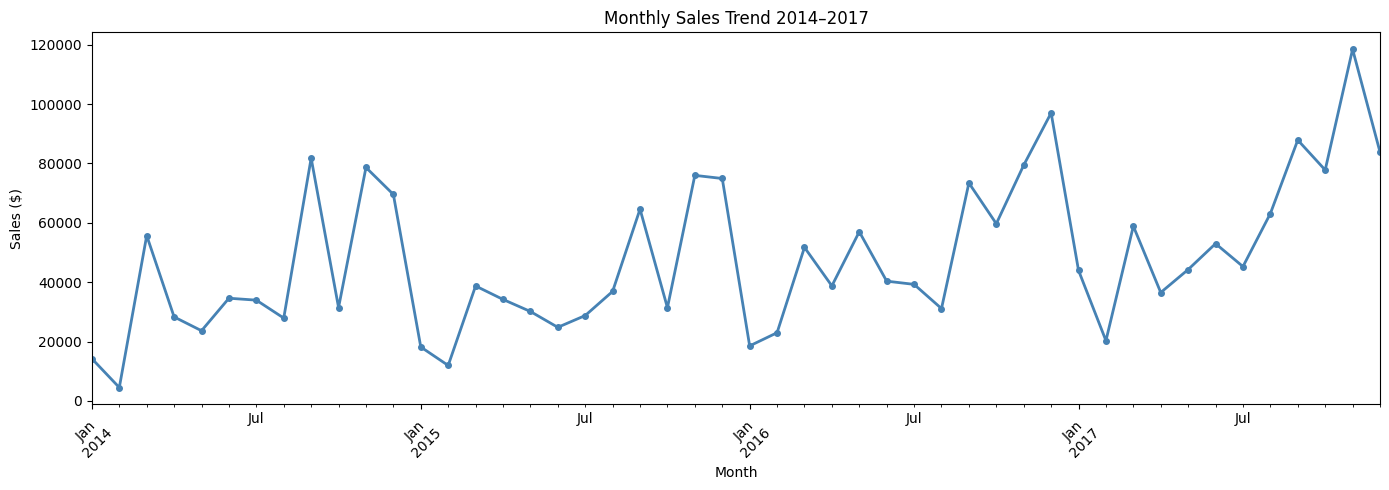

In [12]:
import matplotlib.pyplot as plt

monthly = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(14, 5))
monthly.plot(kind='line', marker='o', color='steelblue', linewidth=2, markersize=4)
plt.title('Monthly Sales Trend 2014–2017')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

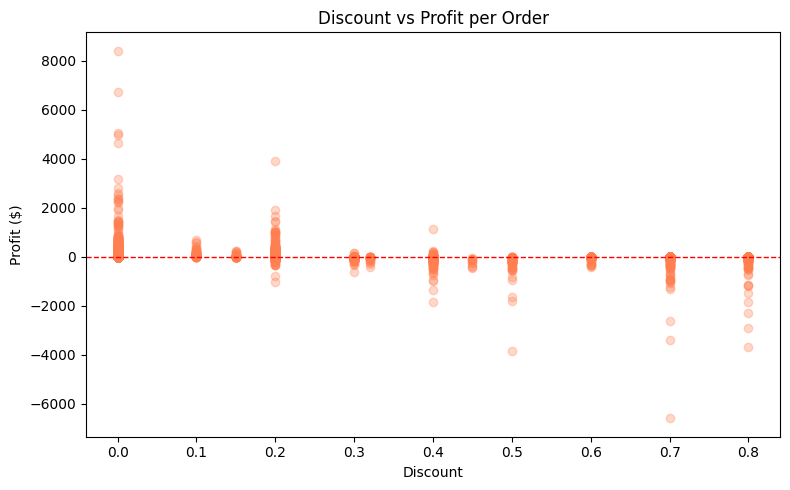

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='coral')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title('Discount vs Profit per Order')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.show()

In [14]:
region = df.groupby('Region')[['Sales','Profit']].sum().round(2)
region['Profit Margin %'] = (region['Profit'] / region['Sales'] * 100).round(2)
region = region.sort_values('Profit Margin %', ascending=False)
print(region)

             Sales     Profit  Profit Margin %
Region                                        
West     725457.82  108418.45            14.94
East     678781.24   91522.78            13.48
South    391721.90   46749.43            11.93
Central  501239.89   39706.36             7.92


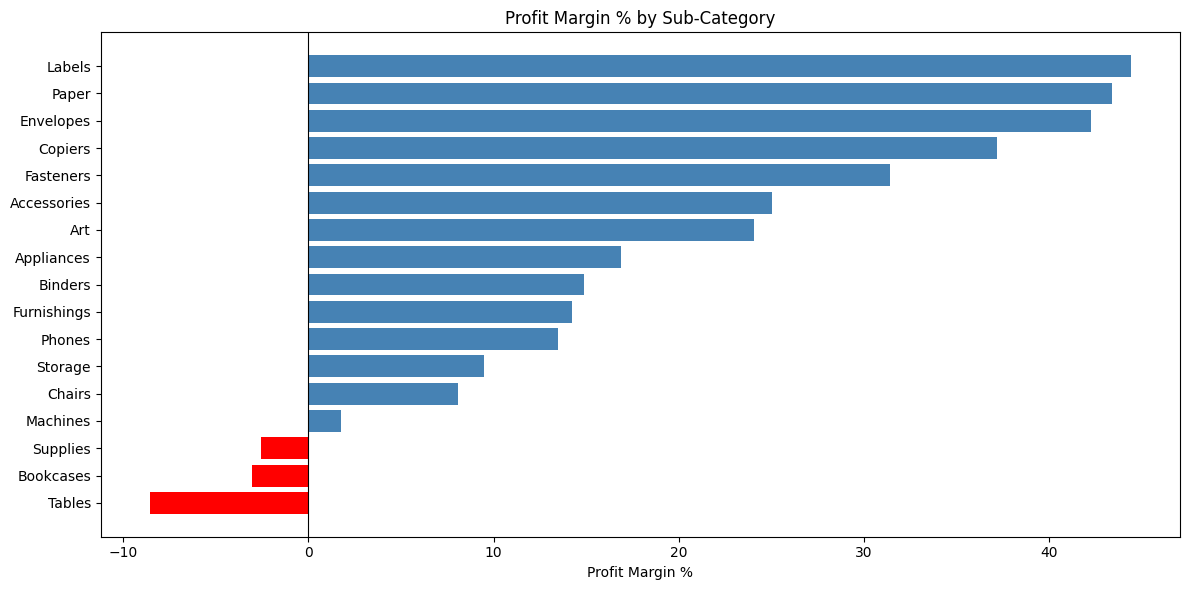

In [15]:
subcat_sorted = subcat.sort_values('Profit Margin %')

colors = ['red' if x < 0 else 'steelblue' for x in subcat_sorted['Profit Margin %']]

plt.figure(figsize=(12, 6))
plt.barh(subcat_sorted.index, subcat_sorted['Profit Margin %'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Profit Margin % by Sub-Category')
plt.xlabel('Profit Margin %')
plt.tight_layout()
plt.show()